# SentinelDC — Production-Oriented 5-Minute Temperature Forecasting

This notebook rebuilds the forecasting pipeline around the actual SentinelDC telemetry scale.

### Design decisions

- Raw telemetry is approximately **1 Hz** and contains ~1.37 million observations.
- Training data is resampled to **10-second intervals** to reduce noise and memory pressure.
- The forecasting target is the **actual temperature exactly 5 minutes after prediction time**.
- No row-shift target is used.
- 5 minutes at 10-second resolution = **30 future intervals**.
- Features use only information available at or before prediction time.
- Train/validation/test are chronological: **70% / 15% / 15%**.
- A persistence baseline is mandatory before judging XGBoost.
- The final model and feature list are saved for the SentinelDC API.
- The replay dataset used by the production simulation is the same 10-second cadence as the model.

> Keep the original 1-second raw dataset. The 10-second dataset is a modeling/replay representation, not a replacement for raw telemetry.

In [4]:
from pathlib import Path
import json
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
BASE_DIR = Path.cwd()

if not (BASE_DIR / "data").exists() and (BASE_DIR.parent / "data").exists():
    BASE_DIR = BASE_DIR.parent

TIME_COLUMN = "Time [Date/Time]"

RESAMPLE_SECONDS = 10
FORECAST_HORIZON_MINUTES = 5
HORIZON = pd.Timedelta(minutes=FORECAST_HORIZON_MINUTES)

MODULES = range(1, 9)

MODULE_TEMP_COLUMNS = [
    f"Module_{i}_Avg_Temp"
    for i in MODULES
]

TARGET_COLUMNS = [
    f"Target_Module_{i}"
    for i in MODULES
]

PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RAW_DATA_PATH = PROCESSED_DIR / "replay_data.csv"

if not RAW_DATA_PATH.exists():
    candidates = list(PROCESSED_DIR.glob("*.csv"))
    if not candidates:
        raise FileNotFoundError(
            "No CSV found in data/processed. "
            "Place replay_data.csv there."
        )
    RAW_DATA_PATH = candidates[0]

print("=" * 70)
print("SENTINELDC — FORECASTING CONFIGURATION")
print("=" * 70)
print("Base directory:", BASE_DIR)
print("Source:", RAW_DATA_PATH)
print("Resampling:", f"{RESAMPLE_SECONDS} seconds")
print("Forecast horizon:", f"+{FORECAST_HORIZON_MINUTES} minutes")
print("Future steps:", int(HORIZON.total_seconds() / RESAMPLE_SECONDS))

SENTINELDC — FORECASTING CONFIGURATION
Base directory: /content
Source: /content/data/processed/AAU_temperature_and_power_use.csv
Resampling: 10 seconds
Forecast horizon: +5 minutes
Future steps: 30


## 2. Load the raw telemetry

In [5]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(RAW_DATA_PATH)

df_raw = pd.read_csv(RAW_DATA_PATH)

print("Rows:", f"{len(df_raw):,}")
print("Columns:", len(df_raw.columns))

if TIME_COLUMN not in df_raw.columns:
    raise ValueError(f"Missing required column: {TIME_COLUMN}")

display(df_raw.head())

Rows: 1,371,363
Columns: 52


,Time [Date/Time],Power Ch 1 (W),Power Ch 2 (W),Power Ch 3 (W),Temperature mod 1 ch 1,Temperature mod 1 ch 2,Temperature mod 1 ch 3,Temperature mod 1 ch 4,Temperature mod 1 ch 5,Temperature mod 1 ch 6,...,Temperature mod 6 ch 3,Temperature mod 6 ch 4,Temperature mod 7 ch 1,Temperature mod 7 ch 2,Temperature mod 7 ch 3,Temperature mod 7 ch 4,Temperature mod 8 ch 1,Temperature mod 8 ch 2,Temperature mod 8 ch 3,Temperature mod 8 ch 4
0,2024-09-16 16:58:30,1268.2,642.7,431.3,24.798231,24.391578,24.724849,24.853324,25.179579,25.222412,...,26.342590,28.182567,27.794631,26.424289,24.814838,29.187404,25.433781,25.807776,23.286057,24.390488
1,2024-09-16 16:58:30,1268.2,642.7,431.3,24.798231,24.391578,24.724849,24.853324,25.179579,25.222412,...,26.342897,28.184878,27.807237,26.422906,24.818216,29.191405,25.434863,25.812099,23.277904,24.405808
2,2024-09-16 16:58:30,1268.2,642.7,431.3,24.800536,24.391732,24.764501,24.860181,25.179116,25.209805,...,26.343358,28.186727,27.800012,26.419217,24.821440,29.192483,25.435636,25.815031,23.271135,24.411070
3,2024-09-16 16:58:30,1268.2,642.7,431.3,24.800536,24.391732,24.764501,24.860181,25.179116,25.209805,...,26.343358,28.186418,27.798474,26.415836,24.820058,29.191098,25.436099,25.818582,23.263290,24.428093
4,2024-09-16 16:58:30,1268.2,642.7,431.3,24.803916,24.395430,24.777924,24.867350,25.179889,25.210112,...,26.342897,28.189192,27.783410,26.415068,24.823743,29.195407,25.437490,25.820897,23.257906,24.409213


## 3. Parse timestamps and inspect data quality

In [6]:
df_raw[TIME_COLUMN] = pd.to_datetime(
    df_raw[TIME_COLUMN],
    errors="coerce"
)

before_invalid = len(df_raw)

df_raw = (
    df_raw
    .dropna(subset=[TIME_COLUMN])
    .sort_values(TIME_COLUMN)
    .reset_index(drop=True)
)

print("Invalid timestamp rows removed:", before_invalid - len(df_raw))
print("Unique timestamps:", f"{df_raw[TIME_COLUMN].nunique():,}")
print(
    "Duplicate timestamp rows:",
    f"{df_raw[TIME_COLUMN].duplicated().sum():,}"
)

timestamps = (
    df_raw[TIME_COLUMN]
    .drop_duplicates()
    .sort_values()
)

diffs = timestamps.diff().dropna()

print("\nSampling interval distribution:")
print(diffs.value_counts().head(10))

print("\nTimestamp range:")
print("Start:", timestamps.min())
print("End  :", timestamps.max())

Invalid timestamp rows removed: 0
Unique timestamps: 1,370,788
Duplicate timestamp rows: 575

Sampling interval distribution:
Time [Date/Time]
0 days 00:00:01    1370302
0 days 00:00:02        485
Name: count, dtype: int64

Timestamp range:
Start: 2024-09-16 16:58:30
End  : 2024-10-02 13:53:02


## 4. Collapse duplicate timestamps before resampling

In [7]:
# Aggregate duplicate timestamp rows numerically.
# We intentionally do NOT create 1.37M-row feature matrices yet.

numeric_columns = df_raw.select_dtypes(
    include=[np.number]
).columns.tolist()

if not numeric_columns:
    raise ValueError("No numeric telemetry columns found.")

df_aggregated = (
    df_raw[
        [TIME_COLUMN] + numeric_columns
    ]
    .groupby(TIME_COLUMN, as_index=False)
    .mean()
    .sort_values(TIME_COLUMN)
    .reset_index(drop=True)
)

print("Rows before:", f"{len(df_raw):,}")
print("Rows after duplicate aggregation:", f"{len(df_aggregated):,}")
print(
    "Duplicate timestamps after aggregation:",
    df_aggregated[TIME_COLUMN].duplicated().sum()
)

Rows before: 1,371,363
Rows after duplicate aggregation: 1,370,788
Duplicate timestamps after aggregation: 0


## 5. Create module temperature and power signals

In [8]:
# Identify temperature channels from the ORIGINAL raw dataframe.
# This avoids losing column-name information during numeric aggregation.

module_channel_map = {}

for m in MODULES:
    prefix = f"Temperature mod {m} ch "
    cols = [
        c for c in numeric_columns
        if c.startswith(prefix)
    ]

    if not cols:
        raise ValueError(
            f"No temperature channels found for Module {m}"
        )

    module_channel_map[m] = cols

    df_aggregated[f"Module_{m}_Avg_Temp"] = (
        df_aggregated[cols]
        .mean(axis=1)
    )

power_columns = [
    c for c in [
        "Power Ch 1 (W)",
        "Power Ch 2 (W)",
        "Power Ch 3 (W)",
    ]
    if c in df_aggregated.columns
]

if power_columns:
    df_aggregated["Total_Power"] = (
        df_aggregated[power_columns]
        .sum(axis=1)
    )
else:
    # Keep the feature available even if this dataset lacks power channels.
    df_aggregated["Total_Power"] = 0.0

print("Temperature channels per module:")
for m, cols in module_channel_map.items():
    print(f"  Module {m}: {len(cols)}")

display(
    df_aggregated[
        [TIME_COLUMN, *MODULE_TEMP_COLUMNS, "Total_Power"]
    ].head()
)

Temperature channels per module:
  Module 1: 8
  Module 2: 8
  Module 3: 8
  Module 4: 8
  Module 5: 4
  Module 6: 4
  Module 7: 4
  Module 8: 4


,Time [Date/Time],Module_1_Avg_Temp,Module_2_Avg_Temp,Module_3_Avg_Temp,Module_4_Avg_Temp,Module_5_Avg_Temp,Module_6_Avg_Temp,Module_7_Avg_Temp,Module_8_Avg_Temp,Total_Power
0,2024-09-16 16:58:30,24.882755,26.631025,26.890017,25.444923,27.931353,27.124676,27.055855,24.732969,2342.200000
1,2024-09-16 16:58:31,24.955284,26.675600,26.907202,25.460115,27.990304,27.131427,27.016517,22.979518,2339.028378
2,2024-09-16 16:58:32,24.800276,26.632657,26.829403,25.353619,28.036740,27.247616,26.954812,18.769740,2352.500000
3,2024-09-16 16:58:33,24.800276,26.632657,26.829403,25.353619,28.030932,27.253707,26.954431,18.708028,2331.700000
4,2024-09-16 16:58:34,24.772511,26.626159,26.819875,25.341631,28.029974,27.259646,26.948017,18.650669,2369.400000


## 6. Resample telemetry to 10-second intervals

In [9]:
# ------------------------------------------------------------
# Why 10 seconds?
#
# Raw data: ~1.37M observations at ~1 Hz.
# Modeling every second is unnecessary for a 5-minute thermal
# forecast and causes large intermediate Pandas allocations.
#
# 10-second cadence:
#   ~1.37M rows -> ~137K rows
#   5 minutes   -> 30 future steps
# ------------------------------------------------------------

df_aggregated = (
    df_aggregated
    .set_index(TIME_COLUMN)
)

resample_columns = [
    *MODULE_TEMP_COLUMNS,
    "Total_Power",
]

df_10s = (
    df_aggregated[
        resample_columns
    ]
    .resample(f"{RESAMPLE_SECONDS}s")
    .mean()
)

df_10s = (
    df_10s
    .dropna(
        subset=MODULE_TEMP_COLUMNS,
        how="all"
    )
    .reset_index()
)

print("10-second rows:", f"{len(df_10s):,}")
print("Columns:", len(df_10s.columns))

intervals_10s = (
    df_10s[TIME_COLUMN]
    .diff()
    .dropna()
)

print("\n10-second interval distribution:")
print(intervals_10s.value_counts().head(10))

print(
    "\nExpected interval:",
    pd.Timedelta(seconds=RESAMPLE_SECONDS)
)

10-second rows: 137,128
Columns: 10

10-second interval distribution:
Time [Date/Time]
0 days 00:00:10    137127
Name: count, dtype: int64

Expected interval: 0 days 00:00:10


## 7. Validate the 10-second modeling cadence

In [10]:
# The resampled data should normally be 10 seconds apart.
# Gaps can still exist where the source telemetry has missing periods.

expected_interval = pd.Timedelta(
    seconds=RESAMPLE_SECONDS
)

interval_counts = intervals_10s.value_counts()

exact_ratio = (
    (intervals_10s == expected_interval).mean()
)

print(
    f"Exact {RESAMPLE_SECONDS}-second interval ratio:",
    f"{exact_ratio:.4%}"
)

gap_rows = df_10s[
    df_10s[TIME_COLUMN].diff() != expected_interval
]

print(
    "Non-standard interval boundaries:",
    len(gap_rows)
)

if exact_ratio < 0.95:
    print(
        "WARNING: More than 5% of intervals are irregular. "
        "Inspect source telemetry before training."
    )
else:
    print("✓ Sampling cadence is suitable for modeling.")

Exact 10-second interval ratio: 100.0000%
Non-standard interval boundaries: 1
✓ Sampling cadence is suitable for modeling.


## 8. Build the exact timestamp-based +5-minute target

In [11]:
# ------------------------------------------------------------
# IMPORTANT:
# Do NOT use shift(30) as the target definition.
#
# We define:
#   target_time = prediction_time + 5 minutes
#
# and then perform an exact timestamp lookup.
# ------------------------------------------------------------

target_lookup = df_10s[
    [TIME_COLUMN, *MODULE_TEMP_COLUMNS]
].copy()

target_lookup = target_lookup.rename(
    columns={
        TIME_COLUMN: "_target_time",
        **{
            f"Module_{i}_Avg_Temp":
            f"Target_Module_{i}"
            for i in MODULES
        }
    }
)

forecast_df = df_10s.copy()

forecast_df["_prediction_time"] = (
    forecast_df[TIME_COLUMN]
)

forecast_df["_target_time"] = (
    forecast_df[TIME_COLUMN] + HORIZON
)

forecast_df = forecast_df.merge(
    target_lookup,
    on="_target_time",
    how="left",
    validate="one_to_one"
)

before_target_filter = len(forecast_df)

forecast_df = (
    forecast_df
    .dropna(subset=TARGET_COLUMNS)
    .sort_values(TIME_COLUMN)
    .reset_index(drop=True)
)

print("Rows before target validation:", f"{before_target_filter:,}")
print("Rows after target validation :", f"{len(forecast_df):,}")
print(
    "Rows without exact +5-min target:",
    f"{before_target_filter - len(forecast_df):,}"
)

Rows before target validation: 137,128
Rows after target validation : 137,098
Rows without exact +5-min target: 30


## 9. Verify the forecast horizon — MUST PASS

In [12]:
horizon = (
    forecast_df["_target_time"]
    - forecast_df["_prediction_time"]
)

print("Unique horizons:", horizon.unique())

assert (
    horizon == HORIZON
).all(), "Target horizon is NOT exactly +5 minutes."

print(
    f"✓ Every target is exactly +{FORECAST_HORIZON_MINUTES} minutes."
)

display(
    forecast_df[
        [
            TIME_COLUMN,
            "_prediction_time",
            "_target_time",
            "Module_1_Avg_Temp",
            "Target_Module_1",
        ]
    ].head(10)
)

Unique horizons: <TimedeltaArray>
['0 days 00:05:00']
Length: 1, dtype: timedelta64[ns]
✓ Every target is exactly +5 minutes.


,Time [Date/Time],_prediction_time,_target_time,Module_1_Avg_Temp,Target_Module_1
0,2024-09-16 16:58:30,2024-09-16 16:58:30,2024-09-16 17:03:30,24.789289,22.700960
1,2024-09-16 16:58:40,2024-09-16 16:58:40,2024-09-16 17:03:40,24.623166,22.680593
2,2024-09-16 16:58:50,2024-09-16 16:58:50,2024-09-16 17:03:50,24.486717,22.670895
3,2024-09-16 16:59:00,2024-09-16 16:59:00,2024-09-16 17:04:00,24.351507,22.659403
4,2024-09-16 16:59:10,2024-09-16 16:59:10,2024-09-16 17:04:10,24.193520,22.644077
5,2024-09-16 16:59:20,2024-09-16 16:59:20,2024-09-16 17:04:20,24.021532,22.637653
6,2024-09-16 16:59:30,2024-09-16 16:59:30,2024-09-16 17:04:30,23.900257,22.624821
7,2024-09-16 16:59:40,2024-09-16 16:59:40,2024-09-16 17:04:40,23.777937,22.614991
8,2024-09-16 16:59:50,2024-09-16 16:59:50,2024-09-16 17:04:50,23.650141,22.621743
9,2024-09-16 17:00:00,2024-09-16 17:00:00,2024-09-16 17:05:00,23.538289,22.636671


## 10. Save and inspect the clean forecasting dataset

In [13]:
FORECAST_DATA_PATH = (
    PROCESSED_DIR /
    "forecasting_data_10s.csv"
)

forecast_df.to_csv(
    FORECAST_DATA_PATH,
    index=False
)

print("Saved:", FORECAST_DATA_PATH)
print("Rows:", f"{len(forecast_df):,}")
print("Columns:", len(forecast_df.columns))

# Compact sanity check
print("\nExample:")
example = forecast_df.iloc[0]

print(
    "Prediction time:",
    example["_prediction_time"]
)

print(
    "Target time    :",
    example["_target_time"]
)

print(
    "Module 1 now   :",
    f"{example['Module_1_Avg_Temp']:.3f} °C"
)

print(
    "Module 1 target:",
    f"{example['Target_Module_1']:.3f} °C"
)

Saved: /content/data/processed/forecasting_data_10s.csv
Rows: 137,098
Columns: 20

Example:
Prediction time: 2024-09-16 16:58:30
Target time    : 2024-09-16 17:03:30
Module 1 now   : 24.789 °C
Module 1 target: 22.701 °C


## 11. Feature engineering — lean, past-only features

In [14]:
# ------------------------------------------------------------
# At 10-second cadence:
#
# lag 1  = 10 sec
# lag 3  = 30 sec
# lag 6  = 1 min
# lag 18 = 3 min
# lag 30 = 5 min
#
# All features are calculated only from present/past telemetry.
# No future target is used as an input.
# ------------------------------------------------------------

base = forecast_df[
    [
        TIME_COLUMN,
        "_prediction_time",
        "_target_time",
        "Total_Power",
        *MODULE_TEMP_COLUMNS,
        *TARGET_COLUMNS,
    ]
].copy().reset_index(drop=True)

# Float32 substantially reduces memory.
numeric_base = base.select_dtypes(
    include=[np.number]
).columns

base[numeric_base] = (
    base[numeric_base]
    .astype(np.float32)
)

feature_blocks = []
feature_columns = []

# ------------------------------------------------------------
# Current temperature
# ------------------------------------------------------------

current = base[
    MODULE_TEMP_COLUMNS
].copy()

feature_blocks.append(current)
feature_columns.extend(current.columns.tolist())

# ------------------------------------------------------------
# Temperature lags
# ------------------------------------------------------------

LAGS = [1, 3, 6, 18, 30]

for lag in LAGS:
    block = (
        base[MODULE_TEMP_COLUMNS]
        .shift(lag)
    )

    block.columns = [
        f"{c}_Lag_{lag}"
        for c in MODULE_TEMP_COLUMNS
    ]

    feature_blocks.append(block)
    feature_columns.extend(block.columns.tolist())

# ------------------------------------------------------------
# Rolling means
# ------------------------------------------------------------

ROLLING_MEANS = [3, 6, 30]

for window in ROLLING_MEANS:
    block = (
        base[MODULE_TEMP_COLUMNS]
        .rolling(
            window=window,
            min_periods=window
        )
        .mean()
    )

    block.columns = [
        f"{c}_RollingMean_{window}"
        for c in MODULE_TEMP_COLUMNS
    ]

    feature_blocks.append(block)
    feature_columns.extend(block.columns.tolist())

# ------------------------------------------------------------
# Rolling standard deviation
# ------------------------------------------------------------

for window in [6, 30]:
    block = (
        base[MODULE_TEMP_COLUMNS]
        .rolling(
            window=window,
            min_periods=window
        )
        .std()
    )

    block.columns = [
        f"{c}_RollingStd_{window}"
        for c in MODULE_TEMP_COLUMNS
    ]

    feature_blocks.append(block)
    feature_columns.extend(block.columns.tolist())

# ------------------------------------------------------------
# Temperature changes
# ------------------------------------------------------------

for period in [1, 3, 6, 30]:
    block = (
        base[MODULE_TEMP_COLUMNS]
        -
        base[MODULE_TEMP_COLUMNS].shift(period)
    )

    block.columns = [
        f"{c}_Change_{period}"
        for c in MODULE_TEMP_COLUMNS
    ]

    feature_blocks.append(block)
    feature_columns.extend(block.columns.tolist())

# ------------------------------------------------------------
# Power
# ------------------------------------------------------------

power_features = pd.DataFrame(index=base.index)

power_features["Total_Power"] = (
    base["Total_Power"]
)

power_features["Total_Power_Lag_6"] = (
    base["Total_Power"].shift(6)
)

power_features["Total_Power_Change_6"] = (
    base["Total_Power"]
    - base["Total_Power"].shift(6)
)

feature_blocks.append(power_features)
feature_columns.extend(power_features.columns.tolist())

# ------------------------------------------------------------
# Cross-module thermal state
# ------------------------------------------------------------

cross = pd.DataFrame(index=base.index)

cross["Module_Temp_Mean"] = (
    base[MODULE_TEMP_COLUMNS].mean(axis=1)
)

cross["Module_Temp_STD"] = (
    base[MODULE_TEMP_COLUMNS].std(axis=1)
)

cross["Module_Temp_Max"] = (
    base[MODULE_TEMP_COLUMNS].max(axis=1)
)

cross["Module_Temp_Min"] = (
    base[MODULE_TEMP_COLUMNS].min(axis=1)
)

feature_blocks.append(cross)
feature_columns.extend(cross.columns.tolist())

# ------------------------------------------------------------
# Time features
# ------------------------------------------------------------

prediction_time = pd.to_datetime(
    base["_prediction_time"]
)

time_features = pd.DataFrame(index=base.index)

time_features["Hour"] = (
    prediction_time.dt.hour.astype(np.float32)
)

time_features["Minute"] = (
    prediction_time.dt.minute.astype(np.float32)
)

time_features["Weekday"] = (
    prediction_time.dt.weekday.astype(np.float32)
)

time_features["Is_Weekend"] = (
    (prediction_time.dt.weekday >= 5)
    .astype(np.float32)
)

feature_blocks.append(time_features)
feature_columns.extend(time_features.columns.tolist())

# ------------------------------------------------------------
# Combine exactly once
# ------------------------------------------------------------

X_all = pd.concat(
    feature_blocks,
    axis=1
)

X_all = X_all.loc[
    :,
    ~X_all.columns.duplicated()
].astype(np.float32)

y_all = (
    base[TARGET_COLUMNS]
    .astype(np.float32)
)

valid = (
    X_all.notna().all(axis=1)
    &
    y_all.notna().all(axis=1)
)

X = (
    X_all.loc[valid]
    .reset_index(drop=True)
)

y = (
    y_all.loc[valid]
    .reset_index(drop=True)
)

time_data = (
    base.loc[
        valid,
        [
            TIME_COLUMN,
            "_prediction_time",
            "_target_time",
            *MODULE_TEMP_COLUMNS,
        ]
    ]
    .reset_index(drop=True)
)

print("=" * 70)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 70)
print("Rows before warm-up:", f"{len(X_all):,}")
print("Rows after warm-up :", f"{len(X):,}")
print("Features:", len(feature_columns))
print("Targets:", len(TARGET_COLUMNS))
print(
    "X memory:",
    f"{X.memory_usage(deep=True).sum()/1024**2:.2f} MB"
)

assert len(X) == len(y) == len(time_data)
assert X.index.equals(y.index)
assert X.index.equals(time_data.index)

print("✓ X, y and timestamps are positionally aligned.")

del feature_blocks, X_all, y_all, base
gc.collect()

FEATURE ENGINEERING COMPLETE
Rows before warm-up: 137,098
Rows after warm-up : 137,068
Features: 131
Targets: 8
X memory: 68.50 MB
✓ X, y and timestamps are positionally aligned.


8

## 12. Verify the feature dataset and target alignment

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Time shape:", time_data.shape)

print("Missing X:", int(X.isna().sum().sum()))
print("Missing y:", int(y.isna().sum().sum()))

assert X.isna().sum().sum() == 0
assert y.isna().sum().sum() == 0

horizon_check = (
    pd.to_datetime(time_data["_target_time"])
    - pd.to_datetime(time_data["_prediction_time"])
)

assert (horizon_check == HORIZON).all()

print(
    f"✓ Every training target remains exactly +{FORECAST_HORIZON_MINUTES} minutes."
)

display(
    pd.concat(
        [
            time_data[
                [
                    TIME_COLUMN,
                    "_target_time",
                    "Module_1_Avg_Temp",
                ]
            ],
            y[["Target_Module_1"]],
        ],
        axis=1
    ).head(10)
)

print("\nFirst 15 features:")
print(feature_columns[:15])

print("\nLast 15 features:")
print(feature_columns[-15:])

X shape: (137068, 131)
y shape: (137068, 8)
Time shape: (137068, 11)
Missing X: 0
Missing y: 0
✓ Every training target remains exactly +5 minutes.


,Time [Date/Time],_target_time,Module_1_Avg_Temp,Target_Module_1
0,2024-09-16 17:03:30,2024-09-16 17:08:30,22.700960,22.787661
1,2024-09-16 17:03:40,2024-09-16 17:08:40,22.680593,22.768585
2,2024-09-16 17:03:50,2024-09-16 17:08:50,22.670895,22.756144
3,2024-09-16 17:04:00,2024-09-16 17:09:00,22.659403,22.758808
4,2024-09-16 17:04:10,2024-09-16 17:09:10,22.644077,22.765312
5,2024-09-16 17:04:20,2024-09-16 17:09:20,22.637653,22.788530
6,2024-09-16 17:04:30,2024-09-16 17:09:30,22.624821,22.816710
7,2024-09-16 17:04:40,2024-09-16 17:09:40,22.614992,22.852005
8,2024-09-16 17:04:50,2024-09-16 17:09:50,22.621742,22.883564
9,2024-09-16 17:05:00,2024-09-16 17:10:00,22.636671,22.918705



First 15 features:
['Module_1_Avg_Temp', 'Module_2_Avg_Temp', 'Module_3_Avg_Temp', 'Module_4_Avg_Temp', 'Module_5_Avg_Temp', 'Module_6_Avg_Temp', 'Module_7_Avg_Temp', 'Module_8_Avg_Temp', 'Module_1_Avg_Temp_Lag_1', 'Module_2_Avg_Temp_Lag_1', 'Module_3_Avg_Temp_Lag_1', 'Module_4_Avg_Temp_Lag_1', 'Module_5_Avg_Temp_Lag_1', 'Module_6_Avg_Temp_Lag_1', 'Module_7_Avg_Temp_Lag_1']

Last 15 features:
['Module_5_Avg_Temp_Change_30', 'Module_6_Avg_Temp_Change_30', 'Module_7_Avg_Temp_Change_30', 'Module_8_Avg_Temp_Change_30', 'Total_Power', 'Total_Power_Lag_6', 'Total_Power_Change_6', 'Module_Temp_Mean', 'Module_Temp_STD', 'Module_Temp_Max', 'Module_Temp_Min', 'Hour', 'Minute', 'Weekday', 'Is_Weekend']


## 13. Chronological 70/15/15 train-validation-test split

In [16]:
n = len(X)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

time_train = time_data.iloc[:train_end]
time_val = time_data.iloc[train_end:val_end]
time_test = time_data.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nTrain time:")
print(time_train["_prediction_time"].iloc[0], "→", time_train["_prediction_time"].iloc[-1])

print("\nValidation time:")
print(time_val["_prediction_time"].iloc[0], "→", time_val["_prediction_time"].iloc[-1])

print("\nTest time:")
print(time_test["_prediction_time"].iloc[0], "→", time_test["_prediction_time"].iloc[-1])

assert (
    time_train["_prediction_time"].max()
    <
    time_val["_prediction_time"].min()
)

assert (
    time_val["_prediction_time"].max()
    <
    time_test["_prediction_time"].min()
)

print("\n✓ No temporal overlap between splits.")

Train: (95947, 131) (95947, 8)
Validation: (20560, 131) (20560, 8)
Test: (20561, 131) (20561, 8)

Train time:
2024-09-16 17:03:30 → 2024-09-27 19:34:30

Validation time:
2024-09-27 19:34:40 → 2024-09-30 04:41:10

Test time:
2024-09-30 04:41:20 → 2024-10-02 13:48:00

✓ No temporal overlap between splits.


## 14. Persistence baseline — the benchmark XGBoost must beat

In [17]:
# A useful 5-minute forecast baseline:
# "In five minutes, the temperature will be approximately the
# current temperature."

actual = y_test.to_numpy()

persistence_pred = (
    time_test[MODULE_TEMP_COLUMNS]
    .to_numpy()
)

persistence_mae = mean_absolute_error(
    actual,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        actual,
        persistence_pred
    )
)

persistence_r2 = r2_score(
    actual,
    persistence_pred
)

print(
    f"Persistence: "
    f"MAE={persistence_mae:.6f} °C | "
    f"RMSE={persistence_rmse:.6f} °C | "
    f"R²={persistence_r2:.6f}"
)

Persistence: MAE=0.697870 °C | RMSE=1.373462 °C | R²=-0.923045


## 15. Moving-average baseline

In [18]:
# 5-minute forecast from the recent 60-second average.
# At 10-second cadence, 6 observations = 60 seconds.

WINDOW = 6

all_temp = pd.concat(
    [
        time_train[MODULE_TEMP_COLUMNS],
        time_val[MODULE_TEMP_COLUMNS],
        time_test[MODULE_TEMP_COLUMNS],
    ],
    ignore_index=True
)

moving_average_predictions = []

for idx in range(
    train_end + len(time_val),
    len(all_temp)
):
    start = max(0, idx - WINDOW + 1)

    moving_average_predictions.append(
        all_temp.iloc[
            start:idx + 1
        ].mean().to_numpy()
    )

moving_average_pred = np.asarray(
    moving_average_predictions
)

ma_mae = mean_absolute_error(
    actual,
    moving_average_pred
)

ma_rmse = np.sqrt(
    mean_squared_error(
        actual,
        moving_average_pred
    )
)

ma_r2 = r2_score(
    actual,
    moving_average_pred
)

print(
    f"Moving Average: "
    f"MAE={ma_mae:.6f} °C | "
    f"RMSE={ma_rmse:.6f} °C | "
    f"R²={ma_r2:.6f}"
)

Moving Average: MAE=0.697781 °C | RMSE=1.367870 °C | R²=-0.931862


## 16. Linear Regression benchmark

In [19]:
linear_model = MultiOutputRegressor(
    LinearRegression()
)

start = time.perf_counter()

linear_model.fit(
    X_train,
    y_train
)

linear_seconds = time.perf_counter() - start

linear_pred = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print(
    f"Linear Regression: "
    f"MAE={linear_mae:.6f} °C | "
    f"RMSE={linear_rmse:.6f} °C | "
    f"R²={linear_r2:.6f}"
)

print(
    f"Training time: {linear_seconds:.2f}s"
)

Linear Regression: MAE=0.671095 °C | RMSE=0.930393 °C | R²=-4.471955
Training time: 5.52s


## 17. XGBoost benchmark

In [20]:
# MultiOutputRegressor makes the 8-module setup explicit and
# works consistently across XGBoost versions.

xgb_base = XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model = MultiOutputRegressor(
    xgb_base,
    n_jobs=1
)

start = time.perf_counter()

xgb_model.fit(
    X_train,
    y_train
)

xgb_seconds = time.perf_counter() - start

xgb_pred = xgb_model.predict(
    X_test
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

improvement_vs_persistence = (
    (persistence_mae - xgb_mae)
    / persistence_mae
    * 100
)

print(
    f"XGBoost: "
    f"MAE={xgb_mae:.6f} °C | "
    f"RMSE={xgb_rmse:.6f} °C | "
    f"R²={xgb_r2:.6f}"
)

print(
    f"Training time: {xgb_seconds:.2f}s"
)

print(
    f"Improvement vs persistence: "
    f"{improvement_vs_persistence:.2f}%"
)

XGBoost: MAE=0.371514 °C | RMSE=0.708424 °C | R²=0.262044
Training time: 190.04s
Improvement vs persistence: 46.76%


## 18. Model comparison

In [21]:
results = pd.DataFrame(
    [
        {
            "Model": "Persistence",
            "MAE": persistence_mae,
            "RMSE": persistence_rmse,
            "R2": persistence_r2,
        },
        {
            "Model": "Moving Average",
            "MAE": ma_mae,
            "RMSE": ma_rmse,
            "R2": ma_r2,
        },
        {
            "Model": "Linear Regression",
            "MAE": linear_mae,
            "RMSE": linear_rmse,
            "R2": linear_r2,
        },
        {
            "Model": "XGBoost",
            "MAE": xgb_mae,
            "RMSE": xgb_rmse,
            "R2": xgb_r2,
        },
    ]
)

results["Improvement_vs_Persistence_%"] = (
    (
        persistence_mae
        - results["MAE"]
    )
    / persistence_mae
    * 100
)

results = (
    results
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(results)

results.to_csv(
    MODEL_DIR / "model_comparison.csv",
    index=False
)

best_model_name = results.iloc[0]["Model"]

print(
    "Best MAE model:",
    best_model_name
)

if xgb_mae >= persistence_mae:
    print(
        "\nWARNING: XGBoost does not beat persistence. "
        "Do NOT claim ML superiority yet."
    )
else:
    print(
        "\n✓ XGBoost beats the persistence baseline."
    )

,Model,MAE,RMSE,R2,Improvement_vs_Persistence_%
0,XGBoost,0.371514,0.708424,0.262044,46.764558
1,Linear Regression,0.671095,0.930393,-4.471955,3.836583
2,Moving Average,0.697781,1.367870,-0.931862,0.012675
3,Persistence,0.697870,1.373462,-0.923045,0.000000


Best MAE model: XGBoost

✓ XGBoost beats the persistence baseline.


## 19. Module-level XGBoost metrics

In [22]:
module_metrics = []

for i, m in enumerate(MODULES):

    actual_module = y_test.iloc[:, i]
    predicted_module = xgb_pred[:, i]

    module_metrics.append(
        {
            "Module": f"Module_{m}",
            "MAE": mean_absolute_error(
                actual_module,
                predicted_module
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    actual_module,
                    predicted_module
                )
            ),
            "R2": r2_score(
                actual_module,
                predicted_module
            ),
        }
    )

module_metrics = pd.DataFrame(
    module_metrics
)

display(module_metrics)

module_metrics.to_csv(
    MODEL_DIR / "module_metrics.csv",
    index=False
)

,Module,MAE,RMSE,R2
0,Module_1,0.387461,0.491573,0.275507
1,Module_2,0.173652,0.214976,0.182862
2,Module_3,0.162573,0.212836,0.118654
3,Module_4,0.222908,0.284789,0.272148
4,Module_5,0.115672,0.146957,0.531822
5,Module_6,0.196648,0.239369,0.126147
6,Module_7,0.211446,0.264160,0.300923
7,Module_8,1.501750,1.857950,0.288289


## 20. Actual vs 5-minute forecast

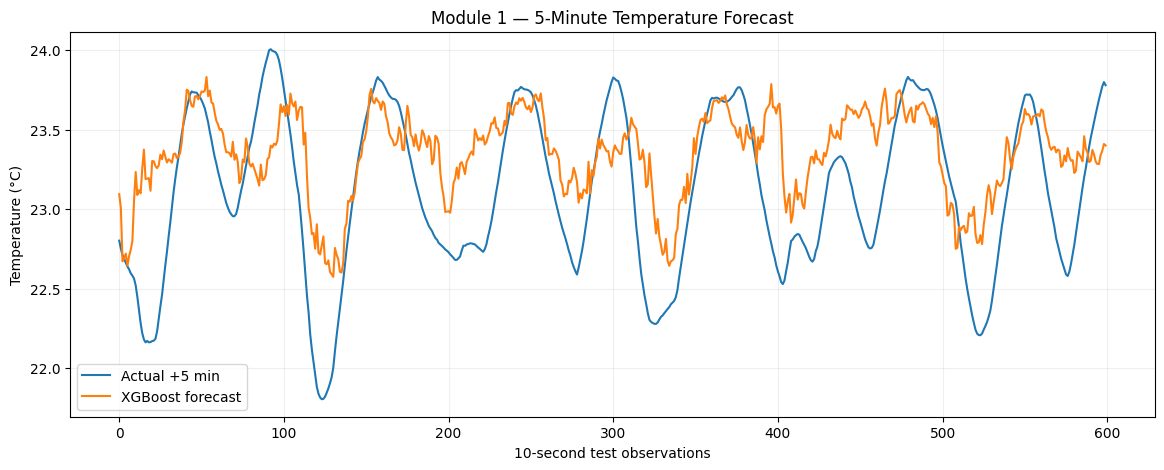

In [23]:
plot_n = min(
    600,
    len(y_test)
)

plt.figure(figsize=(14, 5))

plt.plot(
    y_test.iloc[:plot_n, 0].to_numpy(),
    label="Actual +5 min"
)

plt.plot(
    xgb_pred[:plot_n, 0],
    label="XGBoost forecast"
)

plt.title(
    "Module 1 — 5-Minute Temperature Forecast"
)

plt.xlabel(
    "10-second test observations"
)

plt.ylabel(
    "Temperature (°C)"
)

plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 21. Feature importance

In [24]:
# Each output module has its own XGBoost estimator.
# Show Module 1's feature importance as a representative example.

module_1_estimator = (
    xgb_model.estimators_[0]
)

importance = pd.Series(
    module_1_estimator.feature_importances_,
    index=feature_columns
).sort_values(
    ascending=False
)

display(
    importance.head(25).to_frame(
        "importance"
    )
)

importance.head(50).to_csv(
    MODEL_DIR / "feature_importance_module_1.csv"
)

,importance
Module_1_Avg_Temp_RollingMean_6,0.211502
Module_1_Avg_Temp_RollingMean_3,0.048910
Module_8_Avg_Temp_Change_6,0.037240
Module_7_Avg_Temp_Change_30,0.033159
Module_1_Avg_Temp_RollingStd_6,0.027412
Module_8_Avg_Temp_Change_1,0.025978
Module_8_Avg_Temp_Change_3,0.022286
Module_8_Avg_Temp_RollingMean_30,0.015487
Module_Temp_STD,0.015368
Module_1_Avg_Temp_Change_1,0.013230


## 22. Train the production model on train + validation

In [25]:
# The test set remains untouched for the reported benchmark.
# Production training uses train + validation.

X_final = pd.concat(
    [
        X_train,
        X_val,
    ],
    axis=0
).reset_index(drop=True)

y_final = pd.concat(
    [
        y_train,
        y_val,
    ],
    axis=0
).reset_index(drop=True)

production_base = XGBRegressor(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

production_model = MultiOutputRegressor(
    production_base,
    n_jobs=1
)

start = time.perf_counter()

production_model.fit(
    X_final,
    y_final
)

production_seconds = time.perf_counter() - start

print(
    "Production training complete."
)

print(
    f"Rows used: {len(X_final):,}"
)

print(
    f"Features: {len(feature_columns)}"
)

print(
    f"Training time: {production_seconds:.2f}s"
)

Production training complete.
Rows used: 116,507
Features: 131
Training time: 210.88s


## 23. Save production model and metadata

In [26]:
MODEL_PATH = (
    MODEL_DIR /
    "xgb_temperature_predictor.pkl"
)

FEATURE_PATH = (
    MODEL_DIR /
    "feature_columns.pkl"
)

METADATA_PATH = (
    MODEL_DIR /
    "model_metadata.pkl"
)

METADATA_JSON_PATH = (
    MODEL_DIR /
    "model_metadata.json"
)

joblib.dump(
    production_model,
    MODEL_PATH
)

joblib.dump(
    feature_columns,
    FEATURE_PATH
)

metadata = {
    "model": "XGBoost",
    "wrapper": "MultiOutputRegressor",
    "sampling_seconds": RESAMPLE_SECONDS,
    "prediction_horizon_seconds": 300,
    "prediction_horizon_minutes": 5,
    "targets": TARGET_COLUMNS,
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
    "test_mae": float(xgb_mae),
    "test_rmse": float(xgb_rmse),
    "test_r2": float(xgb_r2),
    "persistence_mae": float(persistence_mae),
    "persistence_rmse": float(persistence_rmse),
    "improvement_vs_persistence_percent": float(
        improvement_vs_persistence
    ),
}

joblib.dump(
    metadata,
    METADATA_PATH
)

with open(
    METADATA_JSON_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print("Saved:")
print(" ", MODEL_PATH)
print(" ", FEATURE_PATH)
print(" ", METADATA_PATH)
print(" ", METADATA_JSON_PATH)

Saved:
  /content/models/xgb_temperature_predictor.pkl
  /content/models/feature_columns.pkl
  /content/models/model_metadata.pkl
  /content/models/model_metadata.json


In [27]:
from google.colab import files

files.download(
    "/content/data/processed/forecasting_data_10s.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 24. Create the production replay dataset

In [29]:
# IMPORTANT:
# The forecasting model was trained on 10-second telemetry.
# Therefore the default replay dataset must use the same cadence.
#
# Raw 1-second data is preserved separately for reference.

RAW_REPLAY_PATH = (
    PROCESSED_DIR /
    "replay_data_raw_1s.csv"
)

MODEL_REPLAY_PATH = (
    PROCESSED_DIR /
    "replay_data.csv"
)

# Save raw/1-second representation
df_raw.to_csv(
    RAW_REPLAY_PATH,
    index=False
)

# Save 10-second representation for Kafka replay
replay_data = df_10s.copy()

replay_data = replay_data[
    [
        TIME_COLUMN,
        *MODULE_TEMP_COLUMNS,
        "Total_Power",
    ]
].copy()

replay_data.to_csv(
    MODEL_REPLAY_PATH,
    index=False
)

print("Raw replay/reference:")
print(" ", RAW_REPLAY_PATH)
print("Rows:", f"{len(df_raw):,}")

print("\nProduction replay:")
print(" ", MODEL_REPLAY_PATH)
print("Rows:", f"{len(replay_data):,}")

print(
    "\n✓ Replay cadence matches model cadence:",
    f"{RESAMPLE_SECONDS} seconds"
)

Raw replay/reference:
  /content/data/processed/replay_data_raw_1s.csv
Rows: 1,371,363

Production replay:
  /content/data/processed/replay_data.csv
Rows: 137,128

✓ Replay cadence matches model cadence: 10 seconds


## 25. Create alert thresholds

In [30]:
# Historical percentile thresholds are a starting point.
# They are NOT claimed to be engineering safety limits.
#
# In a production data-center system, thresholds should ideally
# come from actual thermal specifications / operational policy.

thresholds = {}

for m in MODULES:

    column = f"Module_{m}_Avg_Temp"

    series = (
        df_10s[column]
        .dropna()
    )

    thresholds[column] = {
        "warning": float(
            series.quantile(0.95)
        ),
        "critical": float(
            series.quantile(0.99)
        ),
        "source": "historical_percentiles",
    }

THRESHOLD_PATH = (
    MODEL_DIR /
    "temperature_thresholds.json"
)

with open(
    THRESHOLD_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        thresholds,
        f,
        indent=2
    )

display(
    pd.DataFrame(thresholds).T
)

print(
    "Saved:",
    THRESHOLD_PATH
)

,warning,critical,source
Module_1_Avg_Temp,24.454327,24.886914,historical_percentiles
Module_2_Avg_Temp,30.199681,30.513271,historical_percentiles
Module_3_Avg_Temp,30.101909,30.404007,historical_percentiles
Module_4_Avg_Temp,27.375754,27.74813,historical_percentiles
Module_5_Avg_Temp,33.597495,33.86567,historical_percentiles
Module_6_Avg_Temp,27.054955,27.300954,historical_percentiles
Module_7_Avg_Temp,27.642805,28.047315,historical_percentiles
Module_8_Avg_Temp,24.643963,25.383012,historical_percentiles


Saved: /content/models/temperature_thresholds.json


## 26. Final artifact verification

In [31]:
artifacts = [
    MODEL_PATH,
    FEATURE_PATH,
    METADATA_PATH,
    METADATA_JSON_PATH,
    FORECAST_DATA_PATH,
    MODEL_REPLAY_PATH,
    RAW_REPLAY_PATH,
    THRESHOLD_PATH,
]

print("=" * 70)
print("FINAL ARTIFACT CHECK")
print("=" * 70)

for path in artifacts:
    print(
        "✓" if path.exists() else "✗",
        path
    )

loaded_model = joblib.load(
    MODEL_PATH
)

loaded_features = joblib.load(
    FEATURE_PATH
)

loaded_metadata = joblib.load(
    METADATA_PATH
)

assert (
    loaded_metadata[
        "prediction_horizon_seconds"
    ] == 300
)

assert (
    loaded_metadata[
        "sampling_seconds"
    ] == RESAMPLE_SECONDS
)

assert (
    len(loaded_features)
    == loaded_metadata["feature_count"]
)

# Smoke-test production model shape.
sample_prediction = loaded_model.predict(
    X_test.iloc[:3]
)

assert sample_prediction.shape == (
    3,
    len(TARGET_COLUMNS)
)

print("\nPrediction smoke test:")
print("Shape:", sample_prediction.shape)

print(
    "\n✓ SentinelDC 5-minute forecasting pipeline completed."
)

print(
    "Sampling cadence:",
    f"{RESAMPLE_SECONDS}s"
)

print(
    "Forecast horizon:",
    "+5 minutes"
)

print(
    "Production model:",
    "XGBoost + MultiOutputRegressor"
)

FINAL ARTIFACT CHECK
✓ /content/models/xgb_temperature_predictor.pkl
✓ /content/models/feature_columns.pkl
✓ /content/models/model_metadata.pkl
✓ /content/models/model_metadata.json
✓ /content/data/processed/forecasting_data_10s.csv
✓ /content/data/processed/replay_data.csv
✓ /content/data/processed/replay_data_raw_1s.csv
✓ /content/models/temperature_thresholds.json

Prediction smoke test:
Shape: (3, 8)

✓ SentinelDC 5-minute forecasting pipeline completed.
Sampling cadence: 10s
Forecast horizon: +5 minutes
Production model: XGBoost + MultiOutputRegressor
